# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

## 📦 Imports

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


## Custom Text Corpus for Neural Text Generation

This section defines a larger custom paragraph corpus for training text generation models.

The corpus is used to:
- Convert text into tokenized numerical sequences.
- Create progressive n-gram combinations for next-word prediction.
- Train and compare **SimpleRNN**, **LSTM**, and **GRU** architectures.
- Improve generated sentence quality through a larger vocabulary.

In [2]:
corpus = '''
deep learning is transforming artificial intelligence
machine learning algorithms improve performance through data
neural networks are inspired by the structure of the human brain
recurrent neural networks are useful for sequential data
rnn models process information one step at a time
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
natural language processing enables machines to understand text
tokenization converts text into numerical sequences
embeddings capture semantic relationships between words
training neural networks requires optimization techniques
gradient descent updates model weights iteratively
adam optimizer improves convergence during training
sequence prediction is widely used in language modeling
language models generate human like responses
text generation can be applied in chatbots and assistants
artificial intelligence is changing industries rapidly
large datasets often improve model performance
deep neural networks learn complex patterns
sequence models can create realistic text outputs
lstm networks reduce the vanishing gradient problem
gru networks require fewer computations than lstm
recurrent architectures are effective for language tasks
word prediction improves sentence generation quality
embedding layers convert words into dense vectors
training for more epochs may improve accuracy
hidden layers extract meaningful features
generated text quality depends on training data
machine learning continues to evolve rapidly
'''
print(corpus)


deep learning is transforming artificial intelligence
machine learning algorithms improve performance through data
neural networks are inspired by the structure of the human brain
recurrent neural networks are useful for sequential data
rnn models process information one step at a time
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
natural language processing enables machines to understand text
tokenization converts text into numerical sequences
embeddings capture semantic relationships between words
training neural networks requires optimization techniques
gradient descent updates model weights iteratively
adam optimizer improves convergence during training
sequence prediction is widely used in language modeling
language models generate human like responses
text generation can be applied in chatbots and assistants
artificial intelligence is changing indu

# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 141
X shape: (182, 10)
y shape: (182,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [4]:
rnn_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),  #embedding dimension changed from 32 to 64
    SimpleRNN(128),                                      #hidden unit changed form 64 to 128
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=200, verbose=0)    #epochs changed from 100 to 200
print("Vanilla RNN training completed")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [5]:
lstm_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),   #embedding dimension changed from 32 to 64
    LSTM(128),                                            #hidden unit changed form 64 to 128
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=200, verbose=0)   #epochs changed from 100 to 200
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [6]:
gru_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),  #embedding dimension changed from 32 to 64
    GRU(128),                                            #hidden unit changed form 64 to 128
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=200, verbose=0)  #epochs changed from 100 to 200
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

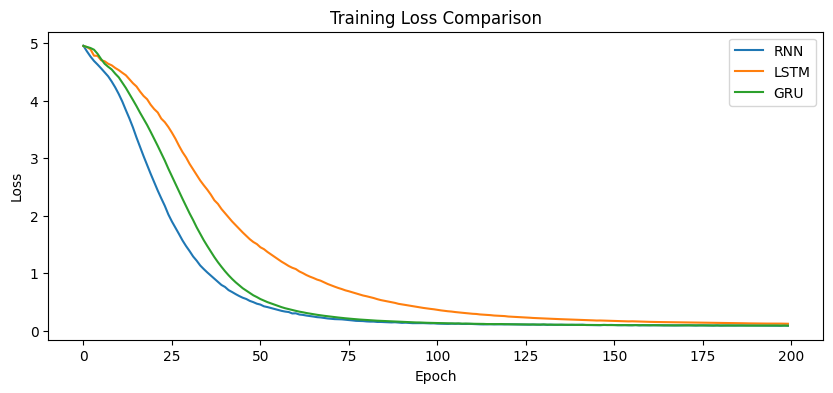

In [7]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [8]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

In [14]:
seed = "LSTM"
NEXT_WORDS = 10       #word generation changed form 5 to 10
print("RNN :", generate_text(rnn_model, seed, NEXT_WORDS))
print("LSTM:", generate_text(lstm_model, seed, NEXT_WORDS))
print("GRU :", generate_text(gru_model, seed, NEXT_WORDS))

RNN : LSTM networks reduce the vanishing gradient problem simpler model weights iteratively
LSTM: LSTM helps remember long term dependencies data data assistants brain brain
GRU : LSTM networks reduce the vanishing gradient problem problem problem problem brain


---
## 🎓 Learning Tasks

| # | Task | Change |
|---|------|--------|
| 1 | Custom paragraph corpus | New domain-rich text |
| 2 | Increase embedding dim | 32 → 64 |
| 3 | Expand training epochs | 100 → 200 |
| 4 | Widen hidden units | 64 → 128 |
| 5 | Generate 10 words | `next_words=10` |


---
## ✅ Conclusions

| Dimension | Vanilla RNN | LSTM | GRU |
|-----------|-------------|------|-----|
| Gates | None | Input + Forget + Output | Reset + Update |
| Long-range memory |vanishing gradient | cell state | simpler cell |
| Parameters | Fewest | Most | Moderate |
| Training speed | Fastest | Slowest | Middle |
| Small-corpus fit | Often overfits quickly | Slower to converge | Good balance |

> **Key insight:** On small corpora LSTM/GRU converge more slowly because they have more parameters to tune,  
> but on larger datasets their gating mechanisms pay off by preserving long-range dependencies the RNN cannot.
